# IOHMM Volatility Regime Visualization

对齐 `HMM/rv_prediction.ipynb` 的可视化风格，针对 IOHMM 的 train/test 结果绘制：
- Actual vs Predicted volatility（基于 `y/state/p_*`）
- Cumulative QLIKE
- Regime（state）可视化
- State 概率曲线与按 dominant state 着色的真实波动率

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

PROJECT_ROOT = Path.cwd().resolve().parent
PIC_DIR = PROJECT_ROOT / 'IOHMM_add' / 'pic'
PIC_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROJECT_ROOT / 'IOHMM' / 'experiments' / 'spy_vol_iohmm_train_results.csv'
TEST_PATH  = PROJECT_ROOT / 'IOHMM' / 'experiments' / 'spy_vol_iohmm_test_results.csv'

print('Train file:', TRAIN_PATH)
print('Test file :', TEST_PATH)
print('Save figs :', PIC_DIR)

Train file: E:\CodeSpace\2026_mafn\cu_saf\IOHMM\experiments\spy_vol_iohmm_train_results.csv
Test file : E:\CodeSpace\2026_mafn\cu_saf\IOHMM\experiments\spy_vol_iohmm_test_results.csv
Save figs : E:\CodeSpace\2026_mafn\cu_saf\IOHMM_add\pic


In [2]:
def load_iohmm_result(path: Path, tag: str) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    if 'Date' in df.columns:
        df = df.rename(columns={'Date': 'date'})
    if 'date' not in df.columns:
        raise ValueError(f'{path.name} 缺少 date/Date 列')
    
    needed = {'y', 'state'}
    miss = [c for c in needed if c not in df.columns]
    if miss:
        raise ValueError(f'{path.name} 缺少必要字段: {miss}')
    
    df['date'] = pd.to_datetime(df['date'])
    df['y'] = pd.to_numeric(df['y'], errors='coerce')
    df['state'] = pd.to_numeric(df['state'], errors='coerce').astype('Int64')
    p_cols = [c for c in df.columns if c.startswith('p_')]
    for c in p_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    
    df = df.sort_values('date').reset_index(drop=True)
    df['split'] = tag
    return df


train = load_iohmm_result(TRAIN_PATH, 'train')
test = load_iohmm_result(TEST_PATH, 'test')

print('train shape:', train.shape)
print('test  shape:', test.shape)
print('train columns:', train.columns.tolist())

train shape: (1258, 7)
test  shape: (252, 7)
train columns: ['date', 'y', 'state', 'p_Low Vol', 'p_Mid Vol', 'p_High Vol', 'split']


In [3]:
# 用 train 估计每个 state 的代表性方差（用于将 state / p_* 映射为预测波动率）
train = train.copy()
train['true_var'] = np.exp(train['y'])
train['true_vol'] = np.sqrt(train['true_var'] * 252.0)

state_var = (
    train.dropna(subset=['state', 'true_var'])
    .groupby('state', as_index=True)['true_var']
    .mean()
)
state_var_map = {int(k): float(v) for k, v in state_var.items()}
state_order = sorted(state_var_map.keys(), key=lambda s: state_var_map[s])

# 与 HMM/rv_prediction.ipynb 对齐：低波动绿，中波动橘，高波动红
REGIME_PALETTE = {
    'low': '#27ae60',
    'mid': '#f39c12',
    'high': '#e74c3c',
}

state_color_map = {}
if len(state_order) == 1:
    state_color_map[state_order[0]] = REGIME_PALETTE['mid']
elif len(state_order) == 2:
    state_color_map[state_order[0]] = REGIME_PALETTE['low']
    state_color_map[state_order[1]] = REGIME_PALETTE['high']
elif len(state_order) >= 3:
    state_color_map[state_order[0]] = REGIME_PALETTE['low']
    state_color_map[state_order[1]] = REGIME_PALETTE['mid']
    state_color_map[state_order[2]] = REGIME_PALETTE['high']
    for s in state_order[3:]:
        state_color_map[s] = '#7f8c8d'

print('State -> mean variance (train):')
for s in state_order:
    print(f'  state {s}: {state_var_map[s]:.8f}, color={state_color_map.get(s)}')

State -> mean variance (train):
  state 0: 0.12815997, color=#27ae60
  state 1: 0.16748067, color=#f39c12
  state 2: 0.21615403, color=#e74c3c


In [4]:
def order_probability_columns(p_cols):
    rank = {'low': 0, 'mid': 1, 'high': 2}
    
    def key_fn(c):
        lc = c.lower()
        for k, r in rank.items():
            if k in lc:
                return (0, r, lc)
        return (1, 99, lc)
    
    return sorted(p_cols, key=key_fn)


def probability_color_map(p_cols):
    cmap = {}
    for i, c in enumerate(p_cols):
        lc = c.lower()
        if 'low' in lc:
            cmap[c] = REGIME_PALETTE['low']
        elif 'mid' in lc:
            cmap[c] = REGIME_PALETTE['mid']
        elif 'high' in lc:
            cmap[c] = REGIME_PALETTE['high']
        else:
            fallback = [REGIME_PALETTE['low'], REGIME_PALETTE['mid'], REGIME_PALETTE['high']]
            cmap[c] = fallback[min(i, len(fallback) - 1)]
    return cmap


def enrich_prediction(df: pd.DataFrame, state_var_map: dict, state_order: list) -> pd.DataFrame:
    out = df.copy()
    out['true_var'] = np.exp(out['y'])
    out['true_vol'] = np.sqrt(out['true_var'] * 252.0)
    
    out['pred_var_hard'] = out['state'].map(state_var_map)
    p_cols = [c for c in out.columns if c.startswith('p_')]
    
    if p_cols:
        p_cols = order_probability_columns(p_cols)
        m = min(len(p_cols), len(state_order))
        out['pred_var_soft'] = 0.0
        for c, s in zip(p_cols[:m], state_order[:m]):
            out['pred_var_soft'] += out[c].fillna(0.0) * state_var_map[s]
        if m == 0:
            out['pred_var_soft'] = np.nan
    else:
        out['pred_var_soft'] = np.nan
    
    out['pred_vol_hard'] = np.sqrt(out['pred_var_hard'] * 252.0)
    out['pred_vol_soft'] = np.sqrt(out['pred_var_soft'] * 252.0)
    return out


train_v = enrich_prediction(train, state_var_map, state_order)
test_v = enrich_prediction(test, state_var_map, state_order)


def to_daily_frequency(df: pd.DataFrame) -> pd.DataFrame:
    """用于画图：把交易日序列补齐为自然日序列（按天）。"""
    out = df.copy().sort_values('date').set_index('date')
    full_idx = pd.date_range(out.index.min(), out.index.max(), freq='D')
    out = out.reindex(full_idx)
    out.index.name = 'date'

    # 状态/数值做前向填充，使图形在自然日连续
    ffill_cols = [c for c in out.columns if c != 'split']
    out[ffill_cols] = out[ffill_cols].ffill()

    if 'state' in out.columns:
        out['state'] = pd.to_numeric(out['state'], errors='coerce').round().astype('Int64')
    if 'split' in out.columns:
        out['split'] = out['split'].ffill().bfill()

    return out.reset_index()


train_plot = to_daily_frequency(train_v)
test_plot = to_daily_frequency(test_v)

print('train original/daily:', len(train_v), len(train_plot))
print('test  original/daily:', len(test_v), len(test_plot))
train_plot[['date', 'y', 'state', 'true_vol', 'pred_vol_hard', 'pred_vol_soft']].head()

train original/daily: 1258 1823
test  original/daily: 252 365


,date,y,state,true_vol,pred_vol_hard,pred_vol_soft
0,2019-01-02,-1.042035,2,9.428124,7.380435,7.380435
1,2019-01-03,-0.995393,2,9.650579,7.380435,7.374974
2,2019-01-04,-0.898303,2,10.130625,7.380435,7.380415
3,2019-01-05,-0.898303,2,10.130625,7.380435,7.380415
4,2019-01-06,-0.898303,2,10.130625,7.380435,7.380415


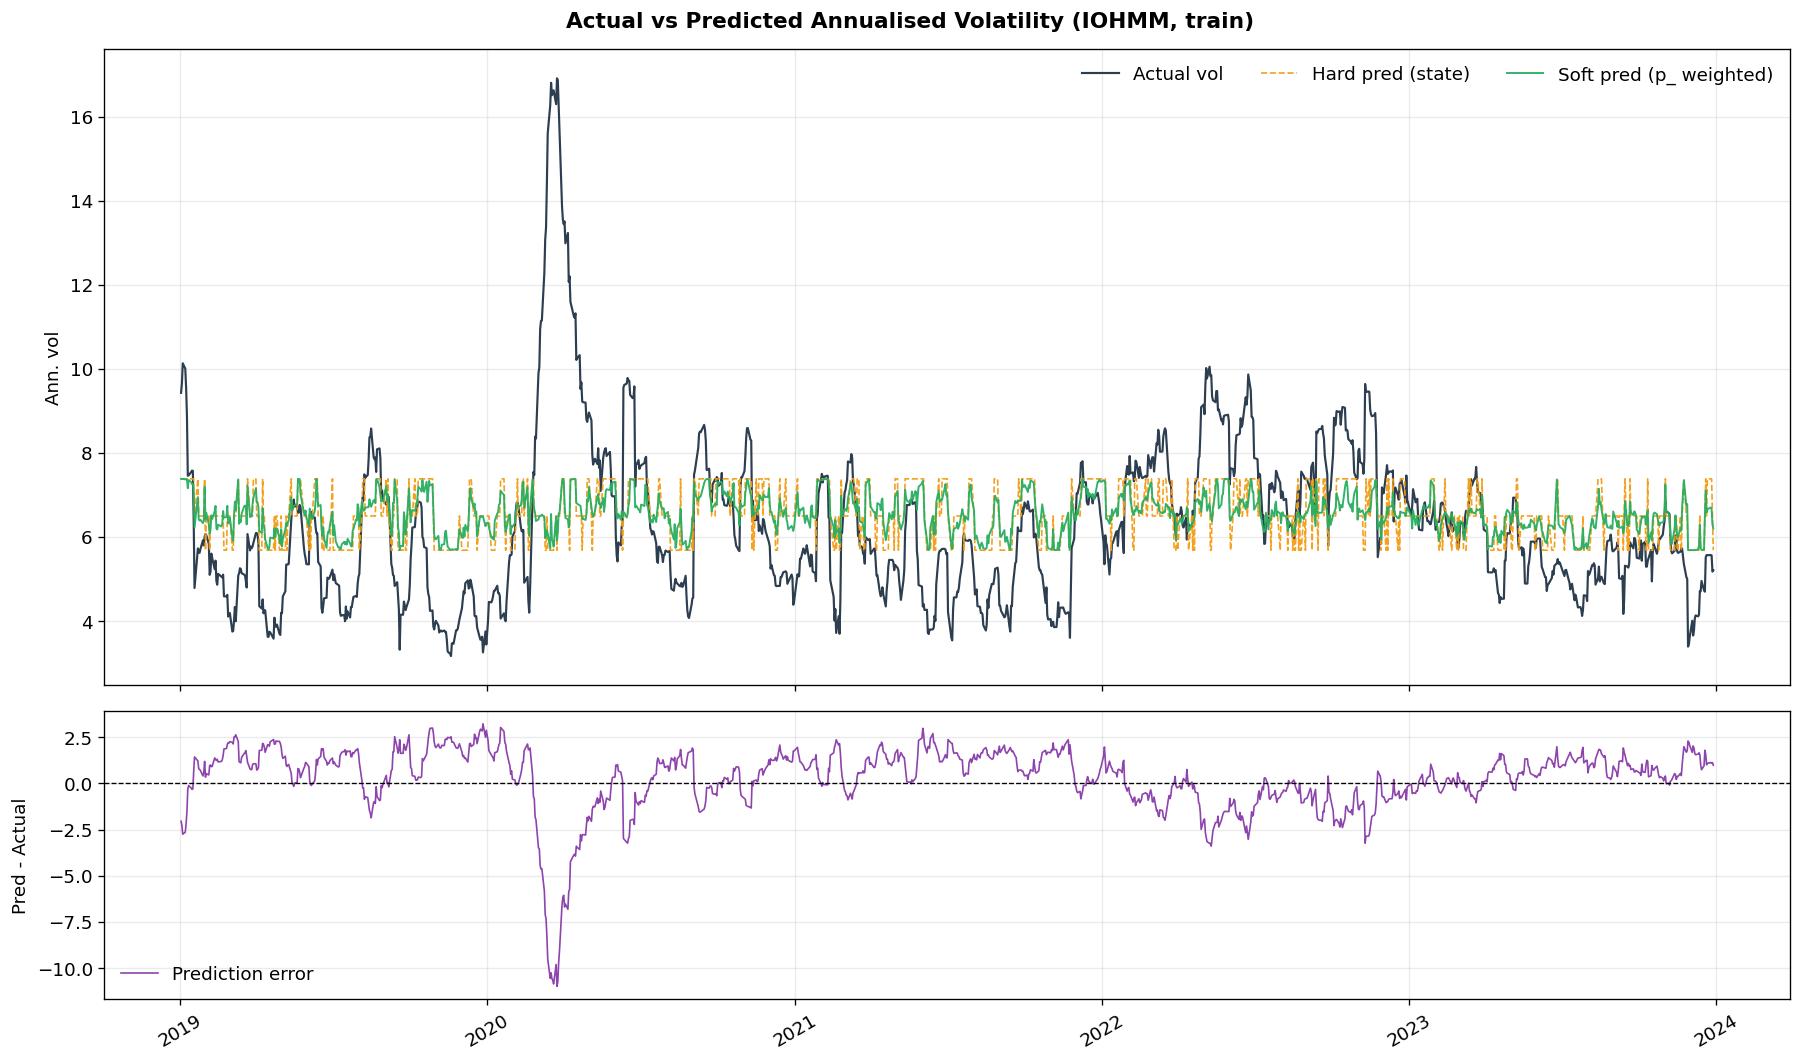

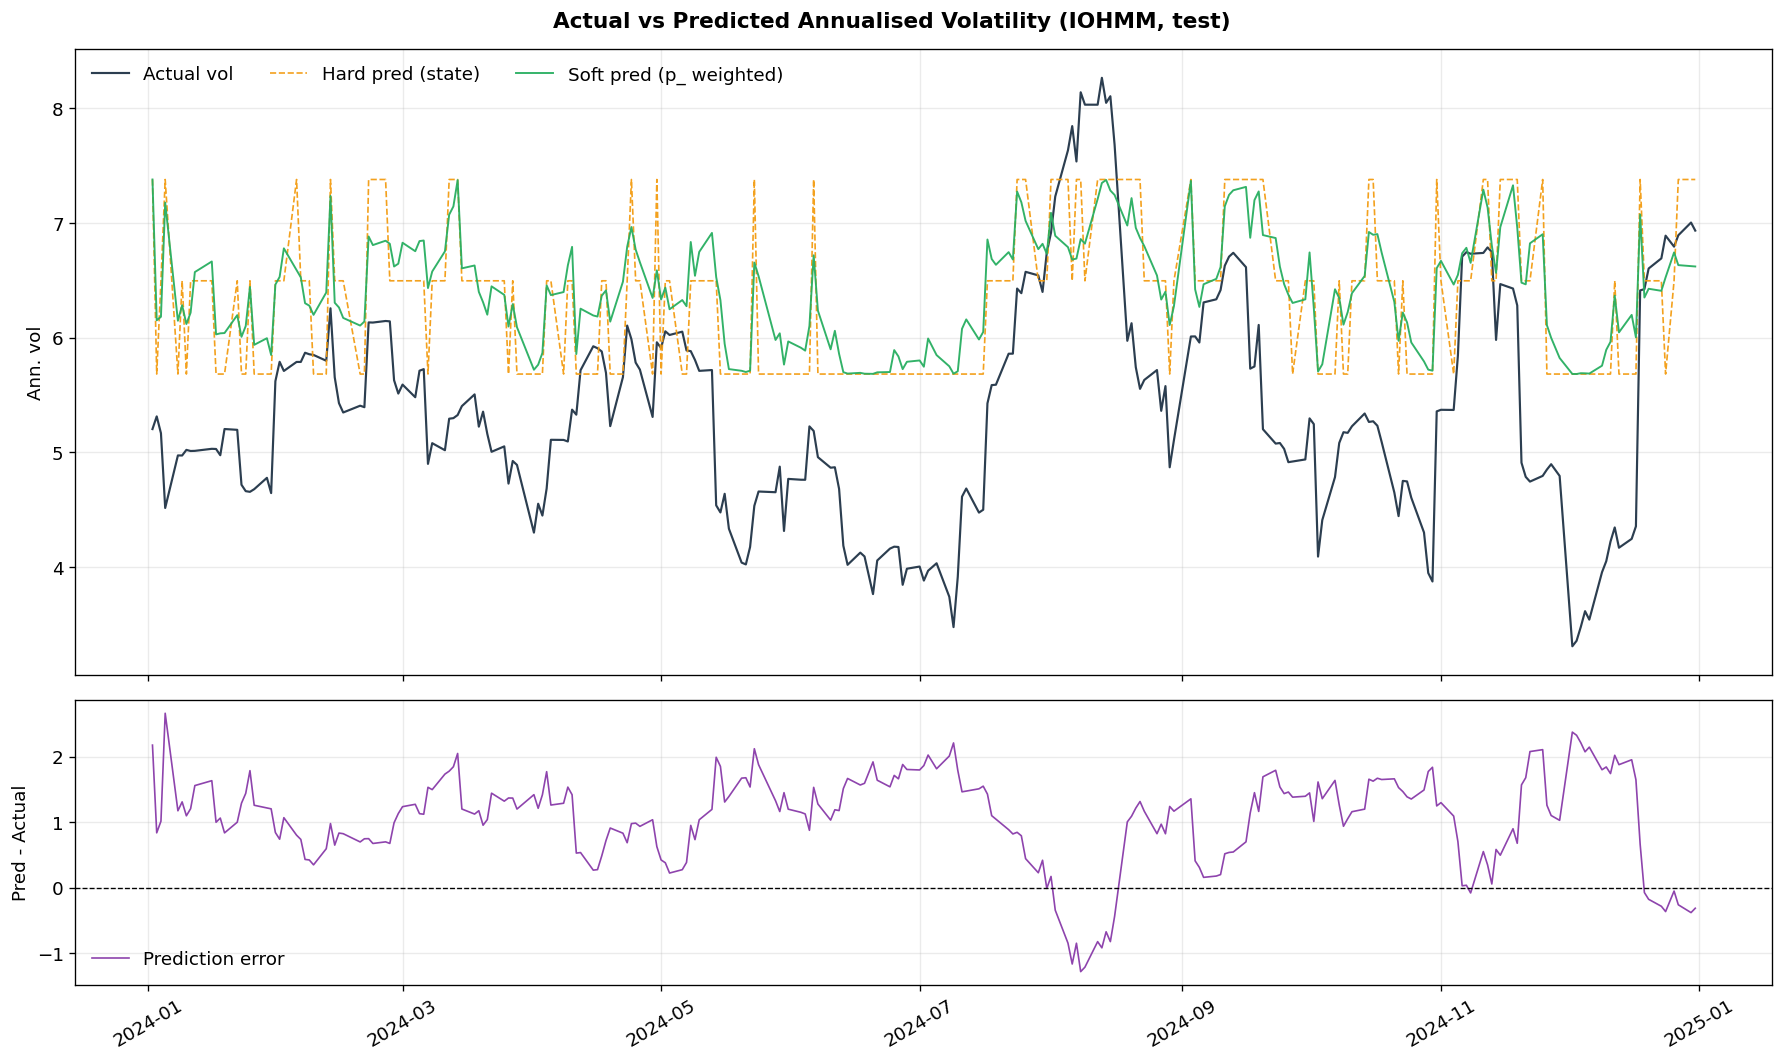

In [5]:
def qlike_series(pred_var: pd.Series, true_var: pd.Series) -> pd.Series:
    eps = 1e-12
    ratio = np.clip(pred_var.values, eps, None) / np.clip(true_var.values, eps, None)
    ql = ratio - np.log(ratio) - 1.0
    return pd.Series(ql, index=pred_var.index)


def plot_forecast(df: pd.DataFrame, split_name: str, save_name: str):
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})
    fig.suptitle(f'Actual vs Predicted Annualised Volatility (IOHMM, {split_name})', fontsize=13, fontweight='bold')
    
    ax = axes[0]
    ax.plot(df['date'], df['true_vol'], color='#2c3e50', lw=1.3, label='Actual vol')
    ax.plot(df['date'], df['pred_vol_hard'], color=REGIME_PALETTE['mid'], lw=1.0, ls='--', alpha=0.95, label='Hard pred (state)')
    if df['pred_vol_soft'].notna().any():
        ax.plot(df['date'], df['pred_vol_soft'], color=REGIME_PALETTE['low'], lw=1.15, alpha=0.95, label='Soft pred (p_ weighted)')
    ax.set_ylabel('Ann. vol')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=3)
    
    ax = axes[1]
    err = df['pred_vol_soft'] - df['true_vol'] if df['pred_vol_soft'].notna().any() else df['pred_vol_hard'] - df['true_vol']
    ax.plot(df['date'], err, color='#8e44ad', lw=1.0, label='Prediction error')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_ylabel('Pred - Actual')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(PIC_DIR / save_name, dpi=200, bbox_inches='tight')
    plt.show()


plot_forecast(train_v, 'train', 'iohmm_vol_train_forecast.png')
plot_forecast(test_v, 'test', 'iohmm_vol_test_forecast.png')

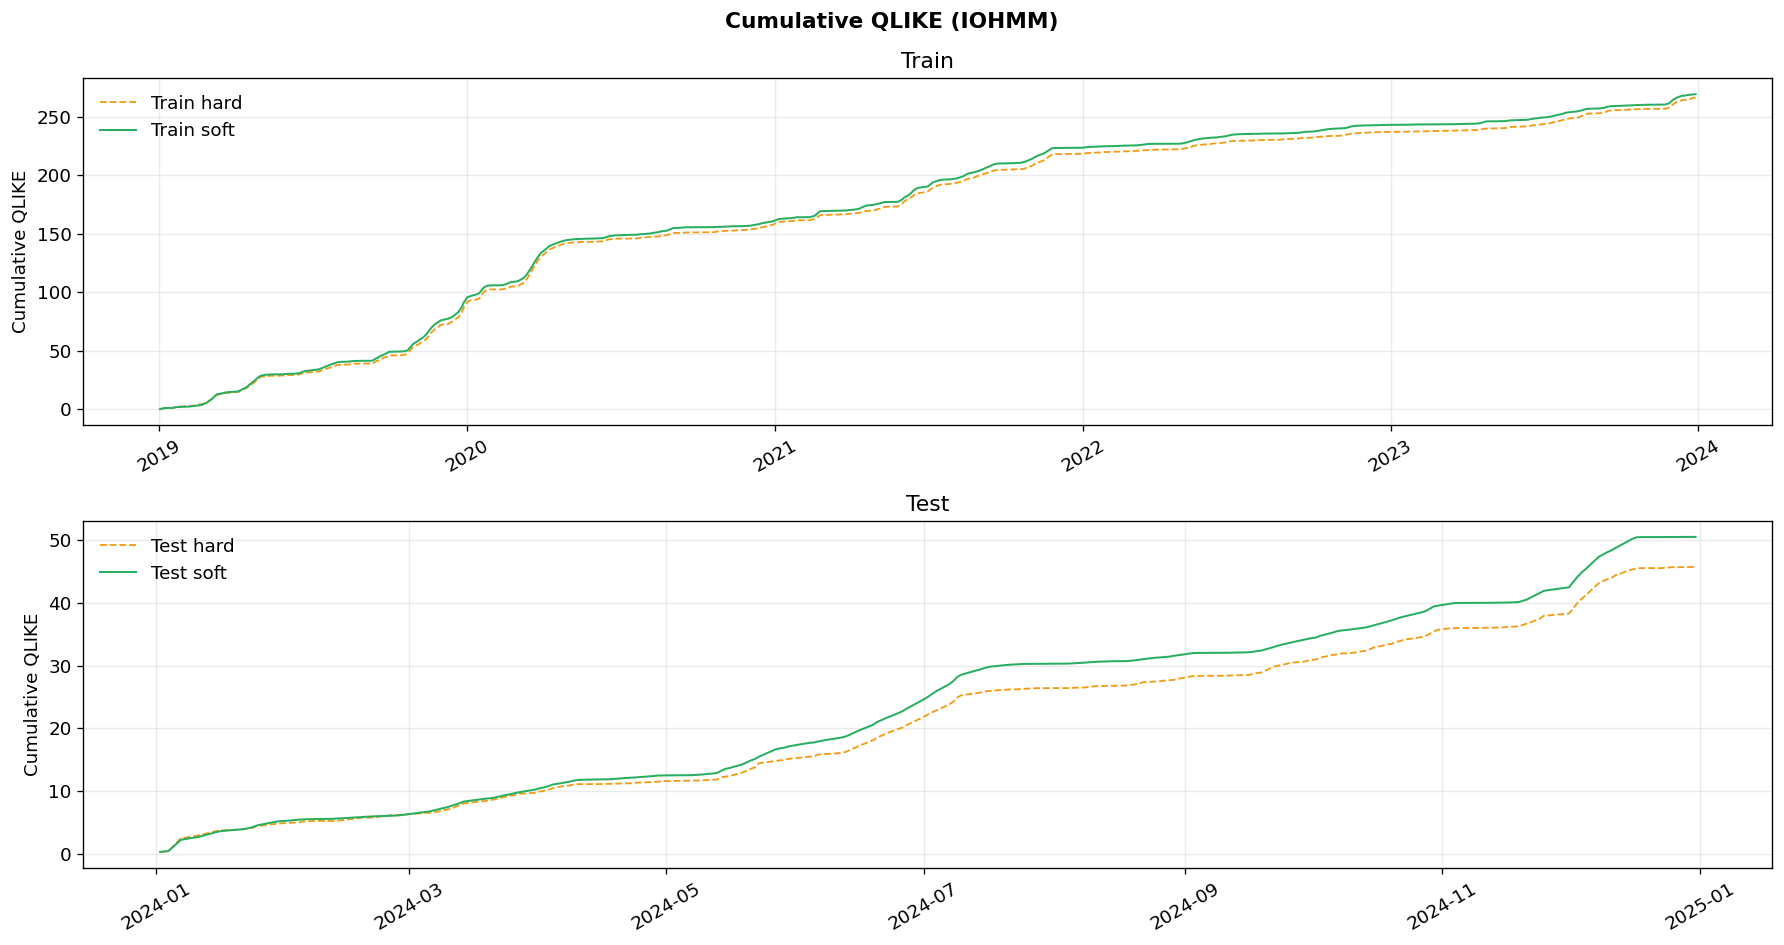

In [6]:
def plot_cum_qlike(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_hard = qlike_series(train_df['pred_var_hard'], train_df['true_var']).cumsum()
    train_soft = qlike_series(train_df['pred_var_soft'].fillna(train_df['pred_var_hard']), train_df['true_var']).cumsum()
    test_hard = qlike_series(test_df['pred_var_hard'], test_df['true_var']).cumsum()
    test_soft = qlike_series(test_df['pred_var_soft'].fillna(test_df['pred_var_hard']), test_df['true_var']).cumsum()
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
    fig.suptitle('Cumulative QLIKE (IOHMM)', fontsize=13, fontweight='bold')
    
    ax = axes[0]
    ax.plot(train_df['date'], train_hard.values, color=REGIME_PALETTE['mid'], lw=1.1, ls='--', label='Train hard')
    ax.plot(train_df['date'], train_soft.values, color=REGIME_PALETTE['low'], lw=1.2, label='Train soft')
    ax.set_title('Train')
    ax.set_ylabel('Cumulative QLIKE')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    
    ax = axes[1]
    ax.plot(test_df['date'], test_hard.values, color=REGIME_PALETTE['mid'], lw=1.1, ls='--', label='Test hard')
    ax.plot(test_df['date'], test_soft.values, color=REGIME_PALETTE['low'], lw=1.2, label='Test soft')
    ax.set_title('Test')
    ax.set_ylabel('Cumulative QLIKE')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    
    for ax in axes:
        for tick in ax.get_xticklabels():
            tick.set_rotation(30)
    
    plt.tight_layout()
    plt.savefig(PIC_DIR / 'iohmm_vol_cum_qlike_train_test.png', dpi=200, bbox_inches='tight')
    plt.show()


plot_cum_qlike(train_plot, test_plot)

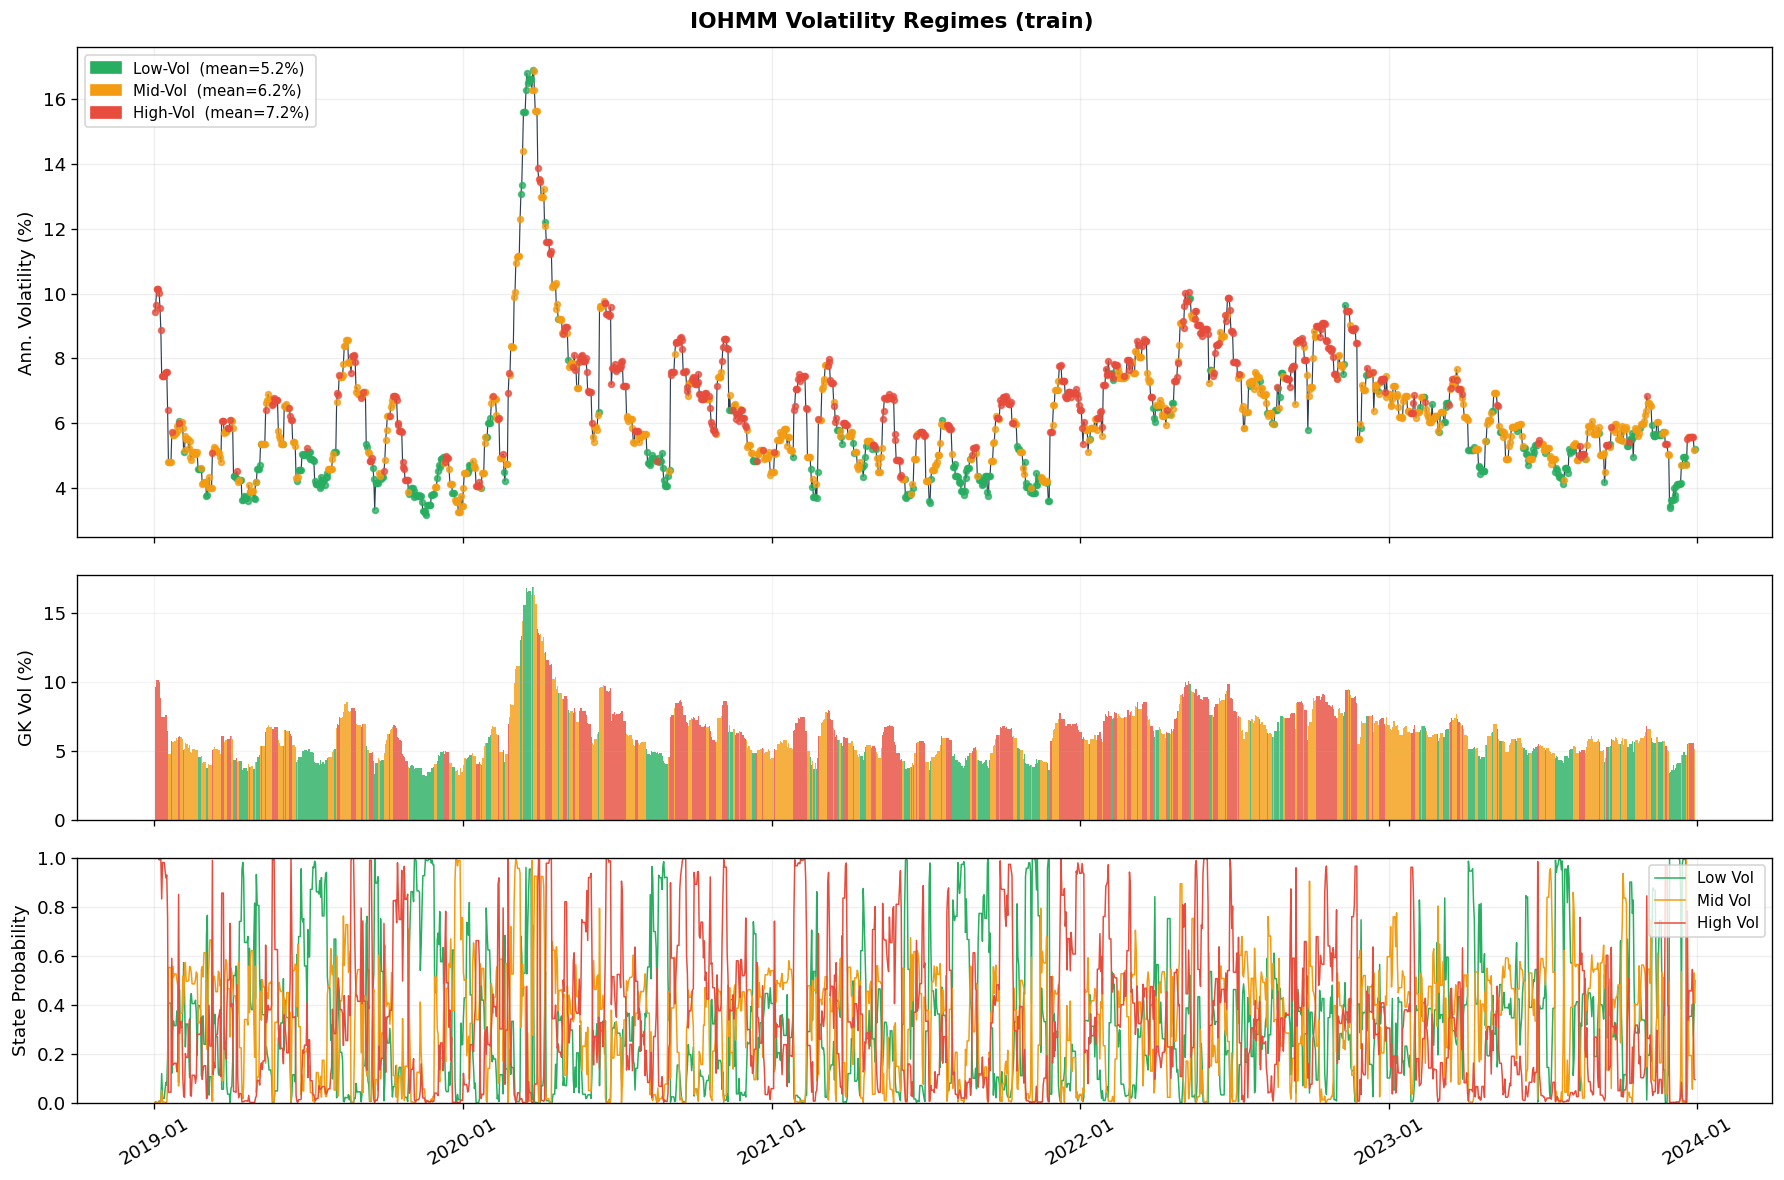

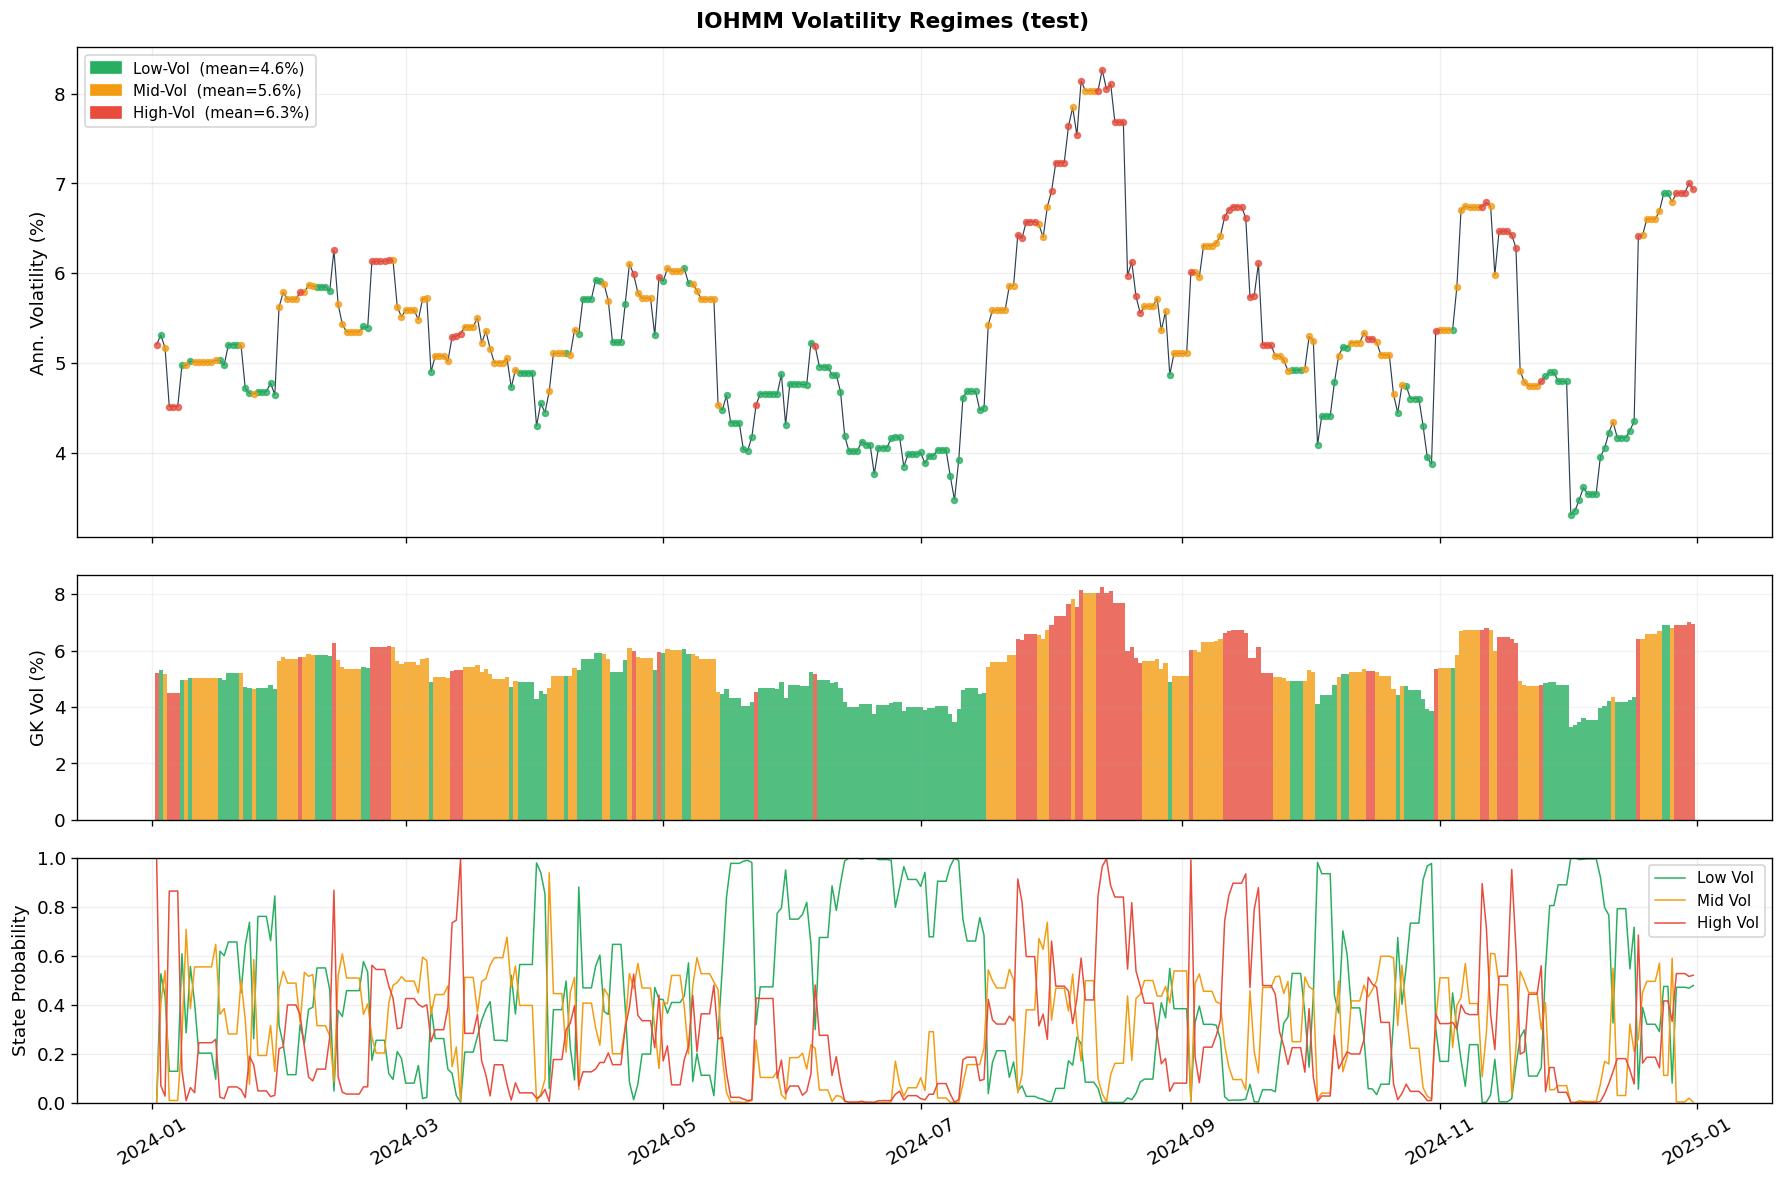

In [7]:
def plot_state_regime(df: pd.DataFrame, split_name: str, save_name: str):
    state_series = pd.to_numeric(df['state'], errors='coerce').fillna(-1).astype(int)
    states = sorted([s for s in state_series.unique().tolist() if s >= 0])
    colors = {s: state_color_map.get(s, '#7f8c8d') for s in states}

    state_label = {}
    if len(state_order) >= 1:
        state_label[state_order[0]] = 'Low-Vol'
    if len(state_order) >= 2:
        state_label[state_order[1]] = 'Mid-Vol'
    if len(state_order) >= 3:
        state_label[state_order[2]] = 'High-Vol'

    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1, 1]})
    fig.suptitle(f'IOHMM Volatility Regimes ({split_name})', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.plot(df['date'], df['true_vol'], color='#2c3e50', lw=0.7, zorder=2)
    for s in states:
        mask = state_series == s
        ax.scatter(df.loc[mask, 'date'], df.loc[mask, 'true_vol'],
                   c=colors[s], s=12, alpha=0.75, zorder=3)
    ax.set_ylabel('Ann. Volatility (%)')

    stat = df.loc[state_series >= 0].groupby(state_series[state_series >= 0])['true_vol'].mean()
    patches = [
        mpatches.Patch(
            color=colors[s],
            label=f"{state_label.get(s, f'State {s}')}  (mean={stat.get(s, np.nan):.1f}%)"
        )
        for s in states
    ]
    if patches:
        ax.legend(handles=patches, loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.2)

    ax = axes[1]
    for s in states:
        mask = state_series == s
        ax.bar(df.loc[mask, 'date'], df.loc[mask, 'true_vol'],
               width=1.0, color=colors[s], alpha=0.8)
    ax.set_ylabel('GK Vol (%)')
    ax.grid(True, alpha=0.15)

    ax = axes[2]
    p_cols = order_probability_columns([c for c in df.columns if c.startswith('p_')])
    p_col_colors = probability_color_map(p_cols)
    for c in p_cols:
        ax.plot(df['date'], df[c], color=p_col_colors[c], lw=0.9, label=c.replace('p_', ''))

    if p_cols:
        ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('State Probability')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(True, alpha=0.2)

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(PIC_DIR / save_name, dpi=200, bbox_inches='tight')
    plt.show()


plot_state_regime(train_plot, 'train', 'iohmm_vol_train_states.png')
plot_state_regime(test_plot, 'test', 'iohmm_vol_test_states.png')

NameError: name 'df_st' is not defined

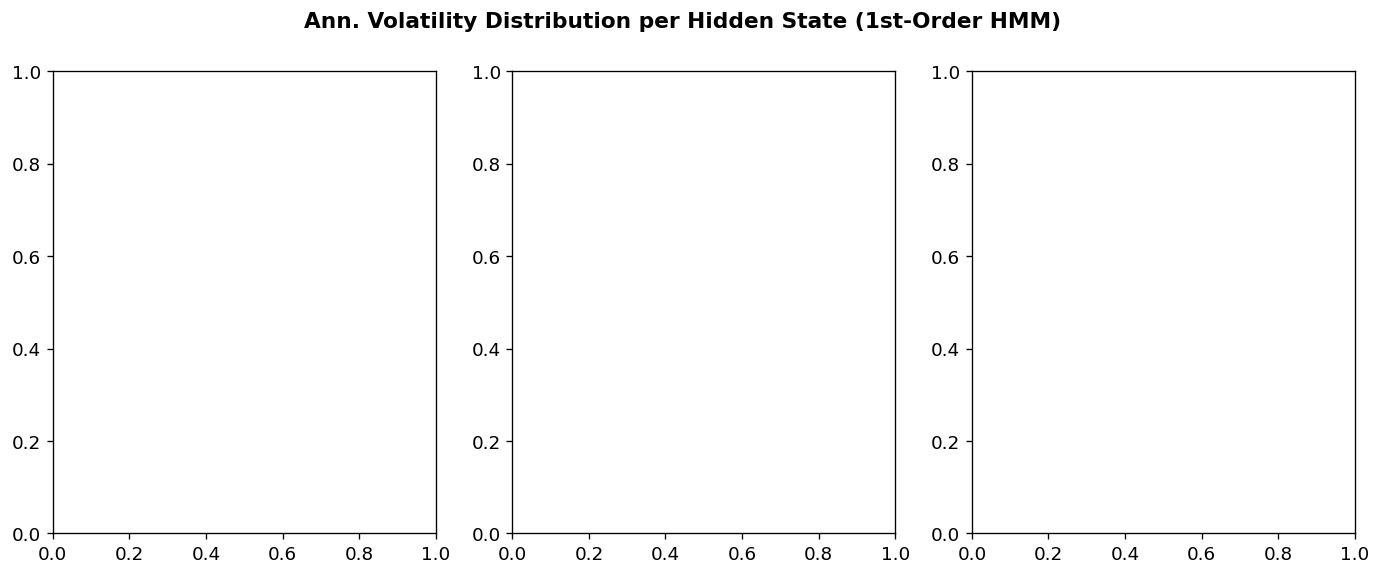

In [11]:
# State-wise annualized volatility distribution (IOHMM train)
plot_df = train_v.dropna(subset=['state', 'true_vol']).copy()
plot_df['state'] = pd.to_numeric(plot_df['state'], errors='coerce').astype('Int64')
plot_df = plot_df.dropna(subset=['state'])
plot_df['state'] = plot_df['state'].astype(int)

states = sorted(plot_df['state'].unique().tolist())
N_STATES = len(states)

# Build labels by volatility rank: low / mid / high
state_label = {}
if len(state_order) >= 1:
    state_label[state_order[0]] = 'Low-Vol'
if len(state_order) >= 2:
    state_label[state_order[1]] = 'Mid-Vol'
if len(state_order) >= 3:
    state_label[state_order[2]] = 'High-Vol'

fig, axes = plt.subplots(1, N_STATES, figsize=(4.8 * N_STATES, 5))
if N_STATES == 1:
    axes = [axes]

fig.suptitle('Ann. Volatility Distribution per Hidden State (IOHMM, train)',
             fontsize=13, fontweight='bold')

for i, s in enumerate(states):
    ax = axes[i]
    data = plot_df.loc[plot_df['state'] == s, 'true_vol']
    color = state_color_map.get(s, '#7f8c8d')

    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85, density=True)

    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='black', lw=1.5, ls='--',
               label=f'mean={mu:.1f}%\nstd ={sigma:.1f}%')

    lbl = state_label.get(s, f'State {s}')
    ax.set_title(f'{lbl}  (n={len(data)})')
    ax.set_xlabel('Ann. Volatility (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(PIC_DIR / 'iohmm_vol_state_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

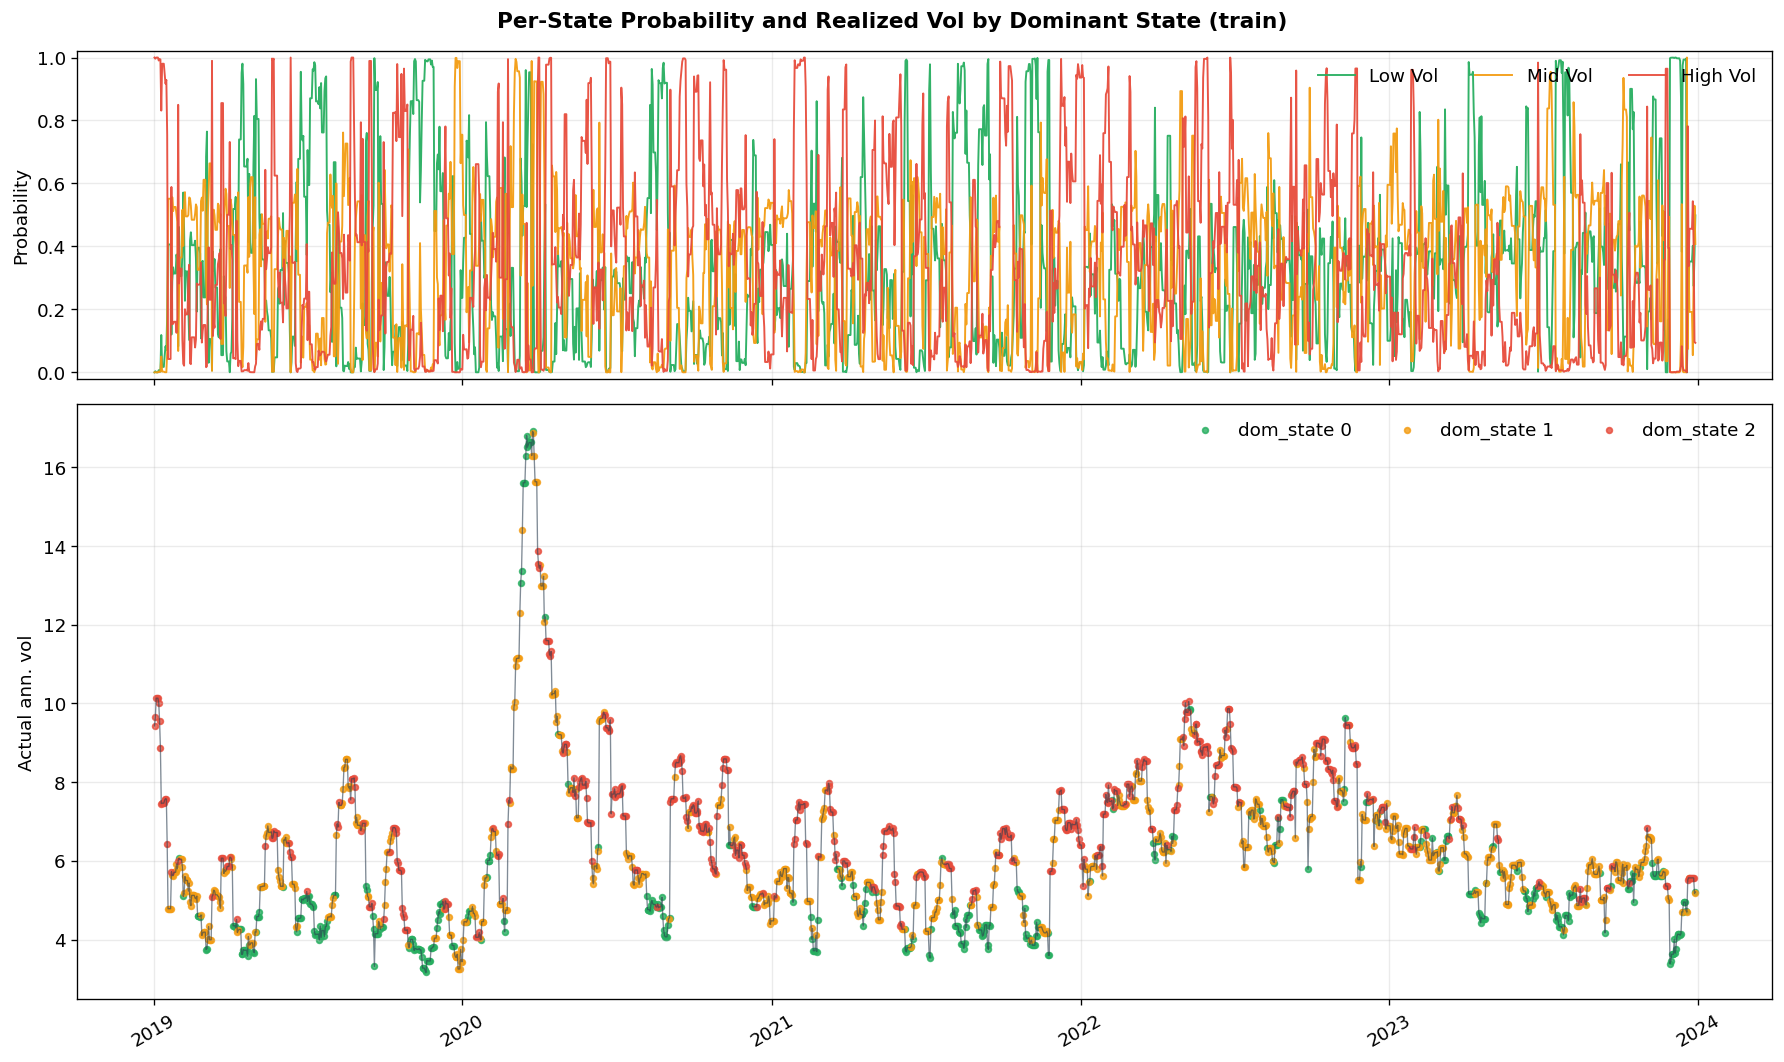

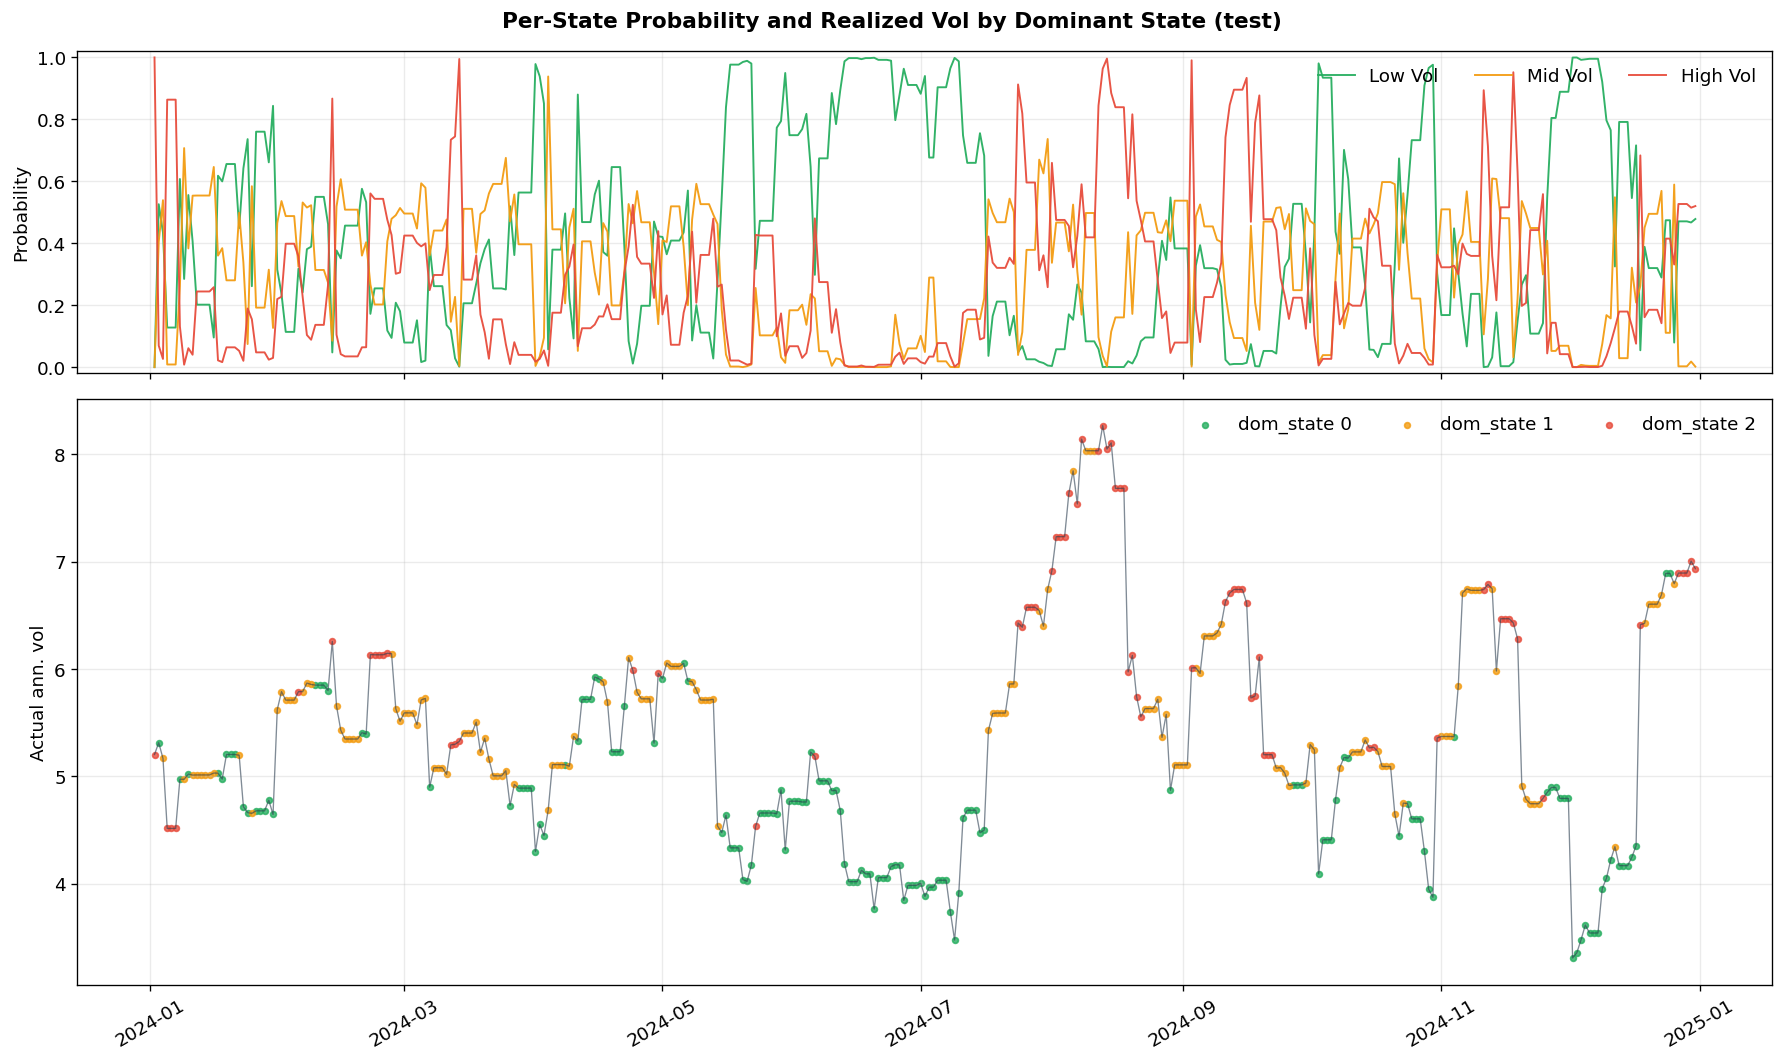

In [8]:
def plot_prob_and_colored_rv(df: pd.DataFrame, split_name: str, save_name: str):
    p_cols = [c for c in df.columns if c.startswith('p_')]
    if not p_cols:
        print(f'[{split_name}] 没有 p_* 列，跳过概率图。')
        return
    
    p_cols = order_probability_columns(p_cols)
    p_col_colors = probability_color_map(p_cols)
    prob_arr = df[p_cols].to_numpy(dtype=float)
    dom_state = np.argmax(prob_arr, axis=1)
    
    rv_plot = df[['date', 'true_vol']].copy()
    rv_plot['dom_state_prob'] = dom_state
    states = sorted(rv_plot['dom_state_prob'].unique().tolist())
    idx_colors = {
        idx: p_col_colors[col]
        for idx, col in enumerate(p_cols)
    }
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [1.1, 2.0]})
    fig.suptitle(f'Per-State Probability and Realized Vol by Dominant State ({split_name})', fontsize=13, fontweight='bold')
    
    ax = axes[0]
    for c in p_cols:
        ax.plot(df['date'], df[c], lw=1.15, alpha=0.95, color=p_col_colors[c], label=c.replace('p_', ''))
    ax.set_ylabel('Probability')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=min(4, len(p_cols)), loc='upper right')
    
    ax = axes[1]
    for s in states:
        m = rv_plot['dom_state_prob'] == s
        ax.scatter(rv_plot.loc[m, 'date'], rv_plot.loc[m, 'true_vol'], s=12, alpha=0.8, color=idx_colors.get(s, '#7f8c8d'), label=f'dom_state {s}')
    ax.plot(rv_plot['date'], rv_plot['true_vol'], color='#2c3e50', lw=0.8, alpha=0.6)
    ax.set_ylabel('Actual ann. vol')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=min(4, len(states)), loc='upper right')
    
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(PIC_DIR / save_name, dpi=200, bbox_inches='tight')
    plt.show()


plot_prob_and_colored_rv(train_plot, 'train', 'iohmm_vol_train_prob_and_rv.png')
plot_prob_and_colored_rv(test_plot, 'test', 'iohmm_vol_test_prob_and_rv.png')

In [9]:
def metric_table(df: pd.DataFrame, split_name: str) -> pd.Series:
    true_var = df['true_var']
    hard_var = df['pred_var_hard']
    soft_var = df['pred_var_soft'].fillna(df['pred_var_hard'])
    
    hard_rmse = np.sqrt(np.mean((df['pred_vol_hard'] - df['true_vol']) ** 2))
    soft_rmse = np.sqrt(np.mean((df['pred_vol_soft'].fillna(df['pred_vol_hard']) - df['true_vol']) ** 2))
    hard_ql = qlike_series(hard_var, true_var).mean()
    soft_ql = qlike_series(soft_var, true_var).mean()
    
    return pd.Series({
        'split': split_name,
        'rmse_hard_vol': hard_rmse,
        'rmse_soft_vol': soft_rmse,
        'qlike_hard': hard_ql,
        'qlike_soft': soft_ql,
    })


metrics = pd.DataFrame([
    metric_table(train_v, 'train'),
    metric_table(test_v, 'test'),
])
metrics

,split,rmse_hard_vol,rmse_soft_vol,qlike_hard,qlike_soft
0,train,1.810205,1.802019,0.143762,0.145511
1,test,1.234303,1.270955,0.128073,0.138130


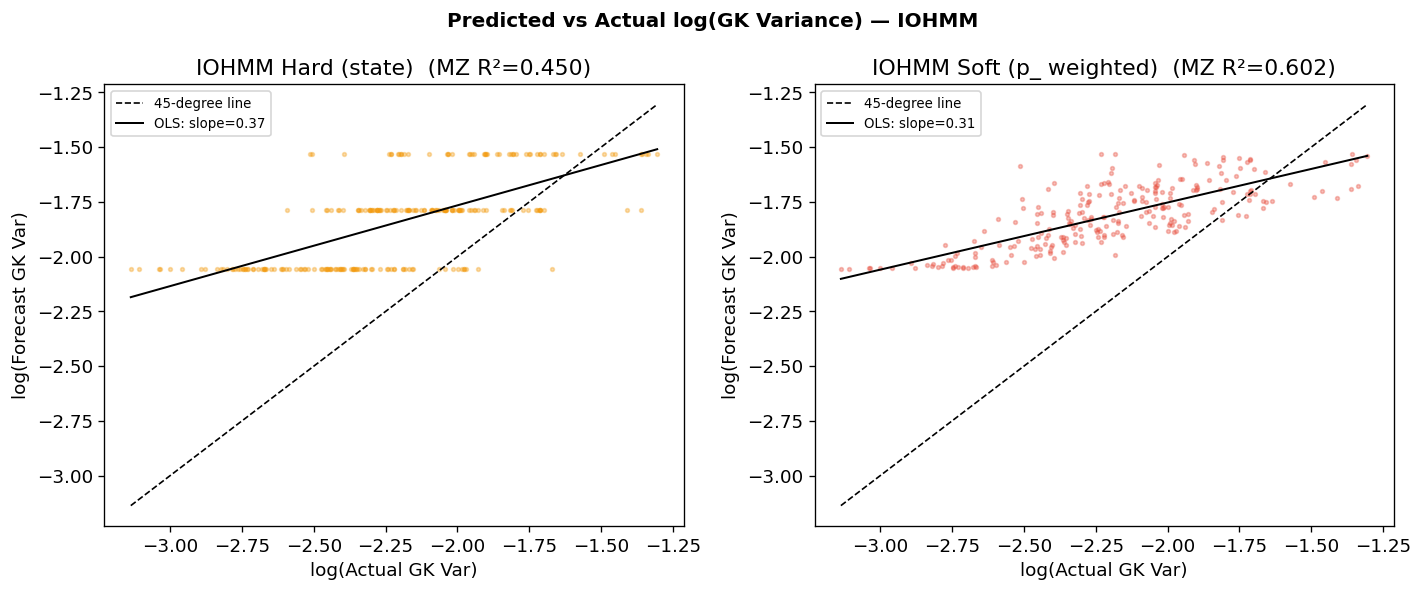

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Predicted vs Actual log(GK Variance) — IOHMM',
             fontsize=12, fontweight='bold')

# 按 rv_prediction.ipynb 的风格：45度线 + OLS 拟合 + MZ R²
for ax, fc, lbl, col in [
    (axes[0], test_v['pred_var_hard'], 'IOHMM Hard (state)', REGIME_PALETTE['mid']),
    (axes[1], test_v['pred_var_soft'].fillna(test_v['pred_var_hard']), 'IOHMM Soft (p_ weighted)', REGIME_PALETTE['high']),
]:
    log_fc = np.log(fc.dropna().clip(1e-10))
    log_act = np.log(test_v['true_var'].reindex(log_fc.index).clip(1e-10))

    valid = np.isfinite(log_fc) & np.isfinite(log_act)
    x = log_act[valid]
    y = log_fc[valid]

    r2 = np.corrcoef(x, y)[0, 1] ** 2 if len(x) > 1 else np.nan

    ax.scatter(x, y, s=5, alpha=0.35, color=col)
    lo, hi = x.min(), x.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='45-degree line')

    coef = np.polyfit(x, y, 1)
    x_fit = np.linspace(lo, hi, 100)
    ax.plot(x_fit, np.polyval(coef, x_fit), color='black', lw=1.2,
            label=f'OLS: slope={coef[0]:.2f}')

    ax.set_xlabel('log(Actual GK Var)')
    ax.set_ylabel('log(Forecast GK Var)')
    ax.set_title(f'{lbl}  (MZ R²={r2:.3f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(PIC_DIR / 'iohmm_vol_scatter.png'),
            dpi=150, bbox_inches='tight')
plt.show()